In [30]:
# Instalar dependencias
!pip install -r /content/requirements.txt

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, classification_report,roc_auc_score, roc_curve)
import seaborn as sns
from IPython.display import display

## Fuentes
- https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/
- https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/
- https://medium.com/@artjovianprojects/deep-learning-project-multilayer-perceptron-e34017941918

## Carga de datos
Los datos fueron preprocesados en Ciencia de Datos: se eliminaron valores atípicos, se seleccionaron variables relevantes y se aplicó estandarización (Z-score). No se llevó a cambo una técnica de balanceo ya que se considera que las clases están naturalmente balanceadas (la diferencia es despreciable para los propósitos del estudio).

Se cargan los conjuntos de entrenamiento y test ya preparados:

In [32]:
train = pd.read_csv("/content/sample_data/train.csv")
test = pd.read_csv("/content/sample_data/test.csv")

print("Primeras 5 filas del conjunto Train:")
display(train.head())

print("\nPrimeras 5 filas del conjunto Test:")
display(test.head())

print("Descripción del conjunto Train: ")
display(train.describe())

print("Descripción del conjunto Test: ")
display(test.describe())

Primeras 5 filas del conjunto Train:


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
0,-1.586893,-1.334958,-0.587860,0.509232,-1.090530,0.0,1.0,0.0,0
1,-1.483875,-1.108159,-0.364785,0.692203,0.307820,0.0,0.0,1.0,0
2,-1.205725,-1.478597,-0.321501,1.317821,-1.518596,0.0,1.0,0.0,1
3,0.452870,0.675995,-0.221617,0.240406,1.221028,0.0,1.0,0.0,1
4,-1.071801,-0.654560,-0.361455,-0.131164,0.578929,0.0,1.0,0.0,0



Primeras 5 filas del conjunto Test:


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
0,-0.968783,-0.276562,-0.041825,0.051806,0.265013,0.0,1.0,0.0,0
1,-0.597917,-0.669680,-0.218287,-0.219835,1.178222,0.0,1.0,0.0,1
2,1.658185,2.067030,-0.191652,0.340336,-1.761167,1.0,0.0,0.0,0
3,0.937057,-0.049763,0.151285,-0.504143,-1.347370,0.0,0.0,1.0,0
4,1.658185,1.613431,-0.474658,0.086993,-0.391355,0.0,1.0,0.0,0


Descripción del conjunto Train: 


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
count,11616.000000,1.161600e+04,1.161600e+04,1.161600e+04,1.161600e+04,11616.000000,11616.000000,11616.000000,11616.000000
mean,0.000893,-9.519168e-15,-1.510882e-16,-1.761676e-16,-2.125634e-17,0.101756,0.714618,0.183626,0.515238
std,0.999587,1.000043e+00,1.000043e+00,1.000043e+00,1.000043e+00,0.302340,0.451616,0.387196,0.499789
min,-2.668586,-3.376150e+00,-1.163861e+00,-2.896833e+00,-1.789705e+00,0.000000,0.000000,0.000000,0.000000
25%,-0.814256,-7.301602e-01,-5.412473e-01,-6.318700e-01,-8.622280e-01,0.000000,0.000000,0.000000,0.000000
50%,0.061400,1.392366e-01,-3.115130e-01,1.264018e-01,5.098029e-02,0.000000,1.000000,0.000000,1.000000
75%,0.885547,6.911146e-01,1.412966e-01,7.041662e-01,9.641886e-01,0.000000,1.000000,0.000000,1.000000
max,2.070259,2.747427e+00,4.556190e+00,2.218599e+00,1.820321e+00,1.000000,1.000000,1.000000,1.000000


Descripción del conjunto Test: 


,air_temp [K],process_temp [K],speed [RPM],torque [Nm],tool_wear [min],product_type_H,product_type_L,product_type_M,target
count,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000,2905.000000
mean,-0.004333,-0.002029,0.009012,-0.002824,-0.036053,0.098451,0.709466,0.192083,0.515318
std,1.029212,1.025555,1.023281,1.005858,1.001149,0.297975,0.454087,0.394005,0.499851
min,-2.565568,-3.149351,-1.103930,-2.896833,-1.789705,0.000000,0.000000,0.000000,0.000000
25%,-0.855463,-0.798200,-0.544577,-0.630814,-0.905035,0.000000,0.000000,0.000000,0.000000
50%,0.056250,0.086317,-0.328160,0.110920,-0.048902,0.000000,1.000000,0.000000,1.000000
75%,0.921604,0.706235,0.154615,0.709092,0.935651,0.000000,1.000000,0.000000,1.000000
max,2.018749,2.747427,4.552861,2.226340,1.806052,1.000000,1.000000,1.000000,1.000000


Train shape: (11616, 9)
Test shape: (2905, 9)

Distribución del target en train:
target
1    5985
0    5631
Name: count, dtype: int64

Distribución del target en test:
target
1    1497
0    1408
Name: count, dtype: int64


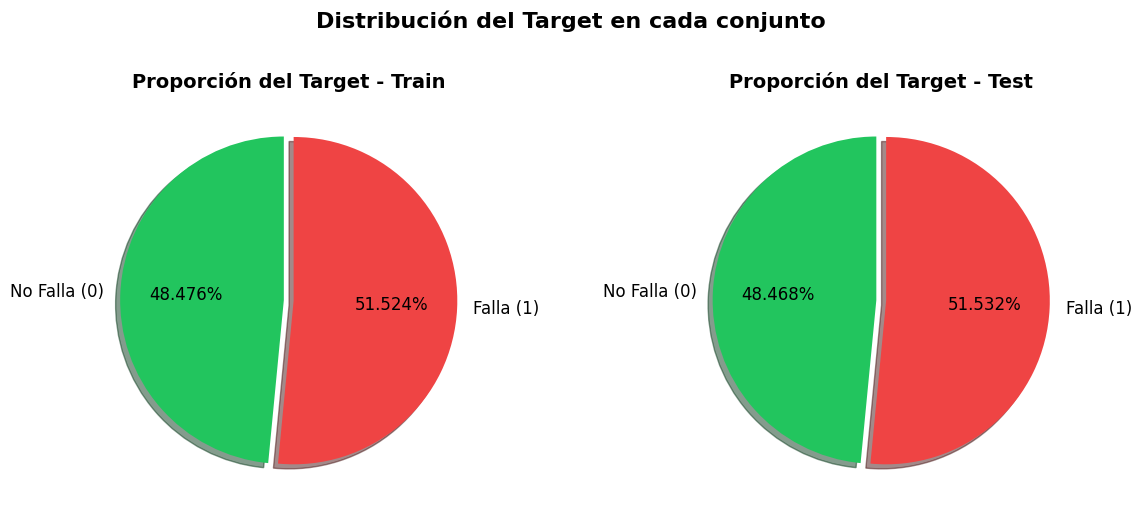

In [33]:
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"\nDistribución del target en train:\n{train['target'].value_counts()}")
print(f"\nDistribución del target en test:\n{test['target'].value_counts()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#22c55e', '#ef4444']
labels = ['No Falla (0)', 'Falla (1)']
explode = (0.03, 0.03)

train_counts = train['target'].value_counts().sort_index()
axes[0].pie(train_counts, labels=labels, autopct='%1.3f%%', startangle=90,
            colors=colors, explode=explode, shadow=True,
            textprops={'fontsize': 12})
axes[0].set_title('Proporción del Target - Train', fontsize=14, fontweight='bold')

test_counts = test['target'].value_counts().sort_index()
axes[1].pie(test_counts, labels=labels, autopct='%1.3f%%', startangle=90,
            colors=colors, explode=explode, shadow=True,
            textprops={'fontsize': 12})
axes[1].set_title('Proporción del Target - Test', fontsize=14, fontweight='bold')

plt.suptitle('Distribución del Target en cada conjunto', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Actividades

Separación de features (X) y target (y) para ambos conjuntos

In [34]:
X_train = train.drop(columns=['target'])
y_train = train['target']

X_test = test.drop(columns=['target'])
y_test = test['target']

print(f"Features de entrada: {X_train.shape[1]} ({list(X_train.columns)})")

Features de entrada: 8 (['air_temp [K]', 'process_temp [K]', 'speed [RPM]', 'torque [Nm]', 'tool_wear [min]', 'product_type_H', 'product_type_L', 'product_type_M'])


### Actividad 1 : Diseño del Modelo

#### Decisiones de diseño

**Arquitectura:**

- **Capa de entrada con 8 neuronas:** corresponde a las 8 features del dataset, son 5 variables continuas estandarizadas (temperatura del aire, temperatura de proceso, velocidad, torque y desgaste de herramienta) más 3 variables dummy del tipo de producto (H, L, M).
- **2 capas ocultas con cantidad de neuronas a determinar:** se eligen 2 capas porque con solo 8 features de entrada, una red más profunda correría riesgo de sobreajuste sin una mejora significativa para el problema en estudio. Se pretende utilizar un patrón "embudo" (neuronas decrecientes) para forzar a la red a comprimir progresivamente la representación de los datos, extrayendo patrones cada vez más abstractos sobre las condiciones que preceden una falla.
- **Capa de salida con 1 neurona:** al tratarse de clasificación binaria (falla / no falla), una única neurona es suficiente para producir la probabilidad de que la máquina falle.

**Funciones de activación:**

- **ReLU en capas ocultas:** es el "estándar" en redes feedforward modernas. A diferencia de sigmoid o tanh, ReLU evita el problema del vanishing gradient, es computacionalmente eficiente (solo una operación de umbral), y produce activaciones dispersas donde solo un subconjunto de neuronas se activa, mejorando la generalización del modelo.
- **Sigmoid en la capa de salida:** mapea la salida al rango [0, 1], lo que permite interpretarla directamente como la probabilidad de falla. Se usa sigmoid y no softmax porque tenemos una sola neurona de salida, softmax se emplea cuando hay 2 o más neuronas de salida en problemas multiclase (ya que normaliza un vector para que las probabilidades sumen 1).

**Función de pérdida: binary_crossentropy**

- Es la función de pérdida estándar y teóricamente óptima para clasificación binaria. Mide qué tan bien las probabilidades predichas se alinean con las etiquetas reales (0 = no falla, 1 = falla). No se exploran otras funciones de pérdida ya que binary_crossentropy es el enfoque canónico para este tipo de problemas.

**Regularización (Dropout):**

- Durante el entrenamiento, se "apagan" aleatoriamente un porcentaje de neuronas en cada paso. Esto evita que las neuronas se co-adapten entre sí, obligando a la red a aprender representaciones más robustas y reduciendo el sobreajuste.

**Hiperparámetros a optimizar automáticamente (Actividad 2):**
La cantidad de neuronas por capa, la tasa de dropout, el learning rate, el optimizador, la tasa de regularización L2 y el batch size serán determinados mediante la búsqueda automatizada de hiperparámetros con Keras Tuner en la Actividad 2.

## Actividad 2: Ajuste de hiperparámetros

Para encontrar la mejor combinación de hiperparámetros se utiliza **Keras Tuner**, una librería que automatiza la búsqueda de hiperparámetros óptimos. En lugar de probar manualmente cada combinación (lo cual sería impráctico dado el número de posibilidades), Keras Tuner:

1. Define un **espacio de búsqueda** con los rangos de cada hiperparámetro
2. Ejecuta múltiples **trials** (entrenamientos con distintas combinaciones)
3. Rankea los resultados según la métrica objetivo (se usará `val_loss`)
4. Devuelve la mejor configuración encontrada

Se utiliza `RandomSearch` como estrategia de búsqueda, que muestrea combinaciones aleatorias del espacio. Esto es más eficiente que un grid search exhaustivo cuando el espacio es grande.

### Hiperparámetros explorados

| Hiperparámetro | Valores explorados |
|---|---|
| Neuronas capa 1 | 32, 64, 128 |
| Neuronas capa 2 | 16, 32, 64 |
| Tasa de aprendizaje | 0.01, 0.001, 0.0001 |
| Dropout | 0.0, 0.2, 0.3, 0.5 |
| Regularización L2 | 0.0, 0.001, 0.01 |
| Optimizador | Adam, SGD (momentum=0.9), RMSprop |


- **Cantidad de neuronas por capa:** determina la capacidad del modelo. Demasiadas llevan a sobreajuste, pocas a subajuste.
- **Learning rate:** controla la velocidad de convergencia. Muy alto genera oscilación, muy bajo estanca el entrenamiento.
- **Tasa de dropout:** controla cuántas neuronas se desactivan. Un valor excesivo degrada el rendimiento, uno muy bajo no regulariza lo suficiente.
- **Optimizador (Adam, SGD, RMSprop):** cada algoritmo actualiza los pesos de forma distinta, y su rendimiento depende del paisaje de la función de pérdida del problema.
- **Regularización L2:** penaliza pesos grandes, complementando al dropout para prevenir sobreajuste.
- **Batch size:** afecta la estabilidad de las estimaciones del gradiente y la velocidad de entrenamiento. No se puede estimar con Keras Tuner, se resolverá luego.

In [35]:
def build_model(hp):
    units_1 = hp.Choice('units_1', [32, 64, 128])
    units_2 = hp.Choice('units_2', [16, 32, 64])

    dropout_rate = hp.Choice('dropout', [0.0, 0.2, 0.3, 0.5])
    l2_value = hp.Choice('l2_reg', [0.0, 0.001, 0.01])

    lr = hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
    opt_name = hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop'])

    regularizer = keras.regularizers.l2(l2_value) if l2_value > 0 else None

    model = keras.Sequential([
        keras.layers.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(units_1, activation='relu',
                           kernel_regularizer=regularizer),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(units_2, activation='relu',
                           kernel_regularizer=regularizer),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    if opt_name == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy', 'recall', 'precision'])
    return model

### Ejecución de la búsqueda
Se configuran 50 trials con RandomSearch y se entrena cada uno por hasta 50 épocas, con `EarlyStopping(patience=10)` para detener el entrenamiento cuando el modelo deja de mejorar, ahorrando tiempo y evitando sobreajuste.
Se eligió `val_loss` como objetivo de optimización en lugar de `val_accuracy` porque, al tratarse de predicción de fallas industriales, donde no detectar una falla puede ser costosos, es preferible estimar bien las probabilidades de falla en lugar de maximizar el porcentaje de aciertos.

#### Mejoras posibles
- Se podrían configurar más trials, ya que el espacio total de combinaciones es de 972 (3×3×4×3×3×3) y con 100 trials solo se explora el 10% del espacio (aunque eventualmente sería equivalente a realizar GridSearch).
- Se podría reemplazar `RandomSearch` por `Hyperband`, que maneja las épocas de forma más inteligente: entrena muchos modelos pocas épocas, descarta los peores y entrena progresivamente más épocas los mejores candidatos.
- Se podría utilizar `BayesianOptimization`, que en vez de muestrear combinaciones al azar, usa los resultados de trials anteriores para guiar la búsqueda hacia regiones más prometedoras del espacio de hiperparámetros.
- Se podrían ampliar los rangos de búsqueda (ej. más valores de neuronas, probar con 1 o 3 capas ocultas en vez de 2 fijas).


In [36]:
import shutil
if os.path.exists('tuner_results'):
    shutil.rmtree('tuner_results')

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=50,
    executions_per_trial=1,
    directory='tuner_results',
    project_name='tp_ia',
    seed=42
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

tuner.search(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Trial 50 Complete [00h 00m 13s]
val_loss: 0.30947232246398926

Best val_loss So Far: 0.11158420145511627
Total elapsed time: 00h 17m 42s


### Resultados de la búsqueda
Se muestran los mejores hiperparámetros encontrados y un resumen de todos los trials ejecutados.

In [37]:
tuner.results_summary(num_trials=3)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

print("\n" + "="*60)
print("MEJOR CONFIGURACIÓN ENCONTRADA:")
print(f"  Neuronas capa 1:   {best_hp.get('units_1')}")
print(f"  Neuronas capa 2:   {best_hp.get('units_2')}")
print(f"  Dropout:           {best_hp.get('dropout')}")
print(f"  Regularización L2: {best_hp.get('l2_reg')}")
print(f"  Learning Rate:     {best_hp.get('learning_rate')}")
print(f"  Optimizador:       {best_hp.get('optimizer')}")
print("="*60)

Results summary
Results in tuner_results/tp_ia
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 17 summary
Hyperparameters:
units_1: 32
units_2: 32
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.01
optimizer: adam
Score: 0.11158420145511627

Trial 31 summary
Hyperparameters:
units_1: 128
units_2: 32
dropout: 0.2
l2_reg: 0.0
learning_rate: 0.001
optimizer: adam
Score: 0.12064690887928009

Trial 40 summary
Hyperparameters:
units_1: 64
units_2: 32
dropout: 0.0
l2_reg: 0.0
learning_rate: 0.001
optimizer: rmsprop
Score: 0.12599147856235504

MEJOR CONFIGURACIÓN ENCONTRADA:
  Neuronas capa 1:   32
  Neuronas capa 2:   32
  Dropout:           0.0
  Regularización L2: 0.0
  Learning Rate:     0.01
  Optimizador:       adam


### Exploración del efecto del batch size
Keras Tuner no varía el batch_size directamente (se pasa a .search()), así que lo exploramos manualmente con la mejor configuración encontrada.

In [38]:
resultados_batch = []
batch_sizes = [16, 32, 64, 128]

for bs in batch_sizes:
    print(f"\n--- Batch Size: {bs} ---")
    model = tuner.hypermodel.build(best_hp)
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=50, batch_size=bs, validation_split=0.20, callbacks=[es], verbose=0)

    results = model.evaluate(X_test, y_test, verbose=0)
    loss, acc = results[0], results[1]


    print(f"  val_loss={loss:.4f}, val_accuracy={acc:.4f}")
    resultados_batch.append({
        'batch_size': bs,
        'val_loss': round(loss, 4),
        'val_accuracy': round(acc, 4),
        'epocas': len(history.history['loss'])
    })

df_batch = pd.DataFrame(resultados_batch)
print("\n=== Comparación de batch sizes ===")

print(df_batch.sort_values('val_loss', ascending=True).to_string(index=False))

min_loss = df_batch['val_loss'].min()
mejor_batch = df_batch.loc[df_batch['val_loss'] == min_loss, 'batch_size'].max()
print(f"\nMejor batch size: {mejor_batch}")


--- Batch Size: 16 ---
  val_loss=0.1233, val_accuracy=0.9532

--- Batch Size: 32 ---
  val_loss=0.1323, val_accuracy=0.9535

--- Batch Size: 64 ---
  val_loss=0.1228, val_accuracy=0.9577

--- Batch Size: 128 ---
  val_loss=0.1308, val_accuracy=0.9487

=== Comparación de batch sizes ===
 batch_size  val_loss  val_accuracy  epocas
         64    0.1228        0.9577      38
         16    0.1233        0.9532      36
        128    0.1308        0.9487      33
         32    0.1323        0.9535      34

Mejor batch size: 64


In [39]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print("=" * 50)
print("CONFIGURACIÓN ÓPTIMA DEL MLP")
print("=" * 50)

print(f"\n--- Arquitectura ---")
print(f"  Capa de entrada:   {X_train.shape[1]} neuronas")
print(f"  Capa oculta 1:     {best_hp.get('units_1')} neuronas (ReLU)")
print(f"  Capa oculta 2:     {best_hp.get('units_2')} neuronas (ReLU)")
print(f"  Capa de salida:    1 neurona (Sigmoid)")

print(f"\n--- Regularización ---")
print(f"  Dropout:           {best_hp.get('dropout')}")
print(f"  Regularización L2: {best_hp.get('l2_reg')}")

print(f"\n--- Entrenamiento ---")
print(f"  Optimizador:       {best_hp.get('optimizer')}")
print(f"  Learning rate:     {best_hp.get('learning_rate')}")
print(f"  Batch size:        {mejor_batch}")
print(f"  Loss:              binary_crossentropy")

CONFIGURACIÓN ÓPTIMA DEL MLP

--- Arquitectura ---
  Capa de entrada:   8 neuronas
  Capa oculta 1:     32 neuronas (ReLU)
  Capa oculta 2:     32 neuronas (ReLU)
  Capa de salida:    1 neurona (Sigmoid)

--- Regularización ---
  Dropout:           0.0
  Regularización L2: 0.0

--- Entrenamiento ---
  Optimizador:       adam
  Learning rate:     0.01
  Batch size:        64
  Loss:              binary_crossentropy


### Entrenamiento del modelo final
Se construye y entrena el modelo con la configuración óptima encontrada (mejores hiperparámetros de Keras Tuner + mejor batch size).
Se aumentan las épocas máximas a 100 y el patience a 15 para permitir una convergencia más completa.

In [40]:
modelo_final = tuner.hypermodel.build(best_hp)
modelo_final.summary()

early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history_final = modelo_final.fit(
    X_train, y_train,
    epochs=100,
    batch_size=int(mejor_batch),
    validation_split=0.20,
    callbacks=[early_stop_final],
    verbose=1
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8846 - loss: 0.2749 - precision: 0.8699 - recall: 0.9118 - val_accuracy: 0.9178 - val_loss: 0.2265 - val_precision: 0.9279 - val_recall: 0.9133
Epoch 2/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9191 - loss: 0.2119 - precision: 0.9091 - recall: 0.9361 - val_accuracy: 0.9234 - val_loss: 0.1984 - val_precision: 0.8922 - val_recall: 0.9703
Epoch 3/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9264 - loss: 0.1897 - precision: 0.9150 - recall: 0.9445 - val_accuracy: 0.9406 - val_loss: 0.1687 - val_precision: 0.9323 - val_recall: 0.9554
Epoch 4/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9352 - loss: 0.1726 - precision: 0.9223 - recall: 0.9543 - val_accuracy: 0.9312 - val_loss: 0.1790 - val_precision: 0.9255 - val_recall: 0.9438
Epoch 5/100
146/146 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9342 - loss: 0.1695 - precision: 0.9240 - recall: 0.9501 - val_accuracy: 0.9221 - val_los

## Actividad 3: Evaluación del modelo

### Curvas de aprendizaje
Se grafican las curvas de loss y accuracy para entrenamiento y validación.
Estas curvas permiten detectar:
- **Overfitting**: val_loss sube mientras train_loss baja
- **Underfitting**: ambas curvas se estancan en valores altos
- **Buen ajuste**: ambas curvas convergen en valores bajos y similares

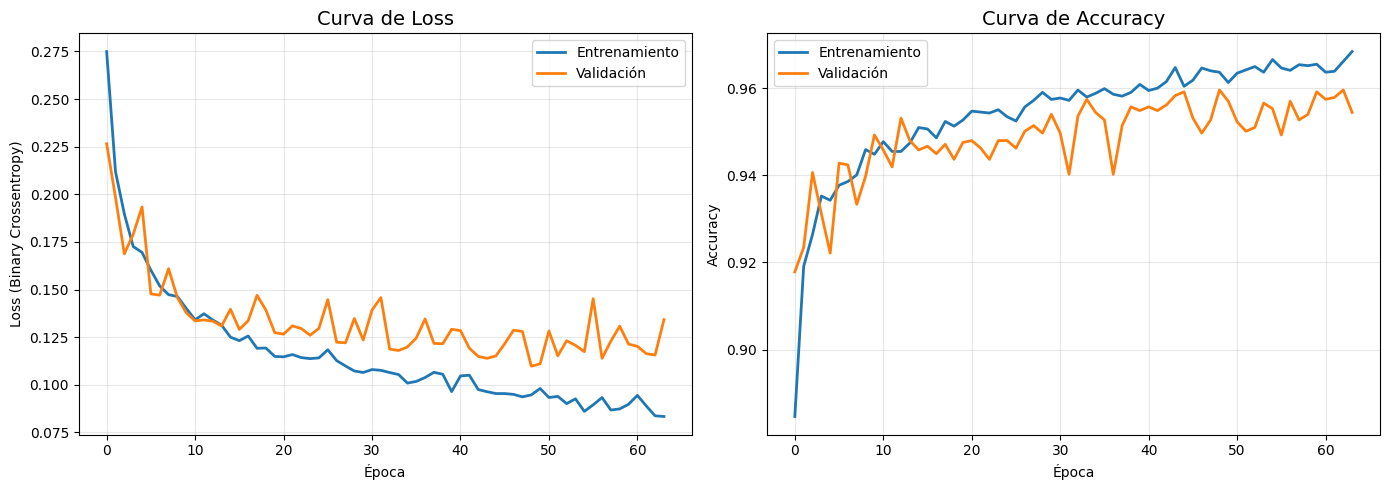

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history_final.history['loss'], label='Entrenamiento', linewidth=2)
ax1.plot(history_final.history['val_loss'], label='Validación', linewidth=2)
ax1.set_title('Curva de Loss', fontsize=14)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (Binary Crossentropy)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history_final.history['accuracy'], label='Entrenamiento', linewidth=2)
ax2.plot(history_final.history['val_accuracy'], label='Validación', linewidth=2)
ax2.set_title('Curva de Accuracy', fontsize=14)
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Se puede apreciar que la generalización sobre datos no vistos (los de validación) es más inestable.
Esto se puede asociar a ruido o pocos datos de entrenamiento/validación.

### Métricas de clasificación
Se calculan métricas estándar para clasificación binaria:
- **Accuracy**: proporción de predicciones correctas
- **Precision**: de los predichos positivos, cuántos son realmente positivos
- **Recall**: de los realmente positivos, cuántos fueron detectados
- **F1-Score**: media armónica de precision y recall
- **AUC-ROC**: capacidad del modelo para distinguir entre clases

In [42]:
y_pred_proba = modelo_final.predict(X_test).flatten()
y_pred = (y_pred_proba >= 0.3).astype(int)

print("=== Reporte de Clasificación ===\n")
print(classification_report(y_test, y_pred,
                            target_names=['No falla (0)', 'Falla (1)']))

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC: {auc_score:.4f}")

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step
=== Reporte de Clasificación ===

              precision    recall  f1-score   support

No falla (0)       0.98      0.93      0.95      1408
   Falla (1)       0.94      0.98      0.96      1497

    accuracy                           0.96      2905
   macro avg       0.96      0.96      0.96      2905
weighted avg       0.96      0.96      0.96      2905

AUC-ROC: 0.9911


### Matriz de confusión
Muestra la distribución de predicciones correctas e incorrectas.
Permite identificar si el modelo falla más en falsos positivos (predice falla cuando no la hay) o falsos negativos (no detecta fallas reales).

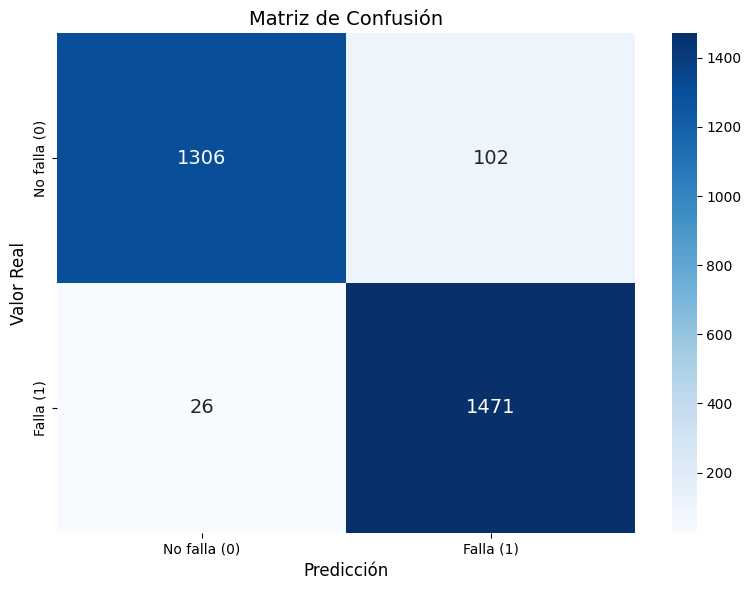

In [43]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No falla (0)', 'Falla (1)'],
            yticklabels=['No falla (0)', 'Falla (1)'],
            ax=ax, annot_kws={"size": 14})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_title('Matriz de Confusión', fontsize=14)
plt.tight_layout()
plt.show()

### Curva ROC
La curva ROC grafica la tasa de verdaderos positivos (TPR) vs. la tasa de falsos positivos (FPR) para distintos umbrales de decisión. Un AUC cercano a 1.0 indica excelente capacidad discriminativa.

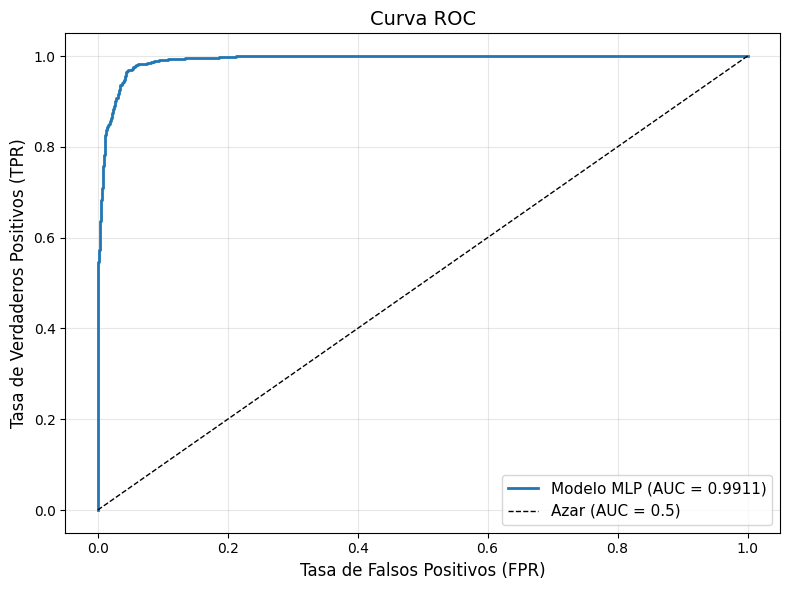

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, linewidth=2, label=f'Modelo MLP (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Actividad 4 y 5
El desarrollo de las actividades 4 y 5 se encuentra en el informe correspondiente.

In [45]:
import sys

print("=" * 50)
print("REQUERIMIENTOS COMPUTACIONALES")
print("=" * 50)

# 1. Dispositivo utilizado (CPU / GPU)
print("\n--- Dispositivo ---")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(f"  GPU detectada: {gpu.name}")
        gpu_details = tf.config.experimental.get_device_details(gpu)
        if gpu_details:
            print(f"  Detalles: {gpu_details}")
else:
    print("  No se detectó GPU. Entrenamiento en CPU.")

print(f"  Dispositivo usado por TensorFlow: {tf.test.gpu_device_name() or 'CPU'}")

# 2. Parámetros del modelo
print("\n--- Parámetros del modelo ---")
total_params = modelo_final.count_params()
trainable = sum(tf.keras.backend.count_params(w) for w in modelo_final.trainable_weights)
non_trainable = sum(tf.keras.backend.count_params(w) for w in modelo_final.non_trainable_weights)

print(f"  Parámetros totales:        {total_params:,}")
print(f"  Parámetros entrenables:    {trainable:,}")
print(f"  Parámetros no entrenables: {non_trainable:,}")

# 3. Estimación de memoria del modelo
model_memory_bytes = total_params * 4
print(f"\n--- Memoria estimada ---")
print(f"  Memoria del modelo (pesos):  {model_memory_bytes / 1024:.2f} KB ({model_memory_bytes / (1024**2):.4f} MB)")

training_memory = model_memory_bytes * 3
print(f"  Memoria entrenamiento (est): {training_memory / 1024:.2f} KB ({training_memory / (1024**2):.4f} MB)")

# 4. Tamaño del dataset en memoria
print(f"\n--- Dataset en memoria ---")
train_mem = X_train.values.nbytes + y_train.values.nbytes
test_mem = X_test.values.nbytes + y_test.values.nbytes
print(f"  Train (X + y): {train_mem / (1024**2):.2f} MB")
print(f"  Test  (X + y): {test_mem / (1024**2):.2f} MB")

REQUERIMIENTOS COMPUTACIONALES

--- Dispositivo ---
  No se detectó GPU. Entrenamiento en CPU.
  Dispositivo usado por TensorFlow: CPU

--- Parámetros del modelo ---
  Parámetros totales:        1,377
  Parámetros entrenables:    1,377
  Parámetros no entrenables: 0

--- Memoria estimada ---
  Memoria del modelo (pesos):  5.38 KB (0.0053 MB)
  Memoria entrenamiento (est): 16.14 KB (0.0158 MB)

--- Dataset en memoria ---
  Train (X + y): 0.80 MB
  Test  (X + y): 0.20 MB
